In [ ]:
from zipfile import ZipFile

zip_path = "/content/Classification_Dataset.zip"
extract_path = "/content/DataSets"

with ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [ ]:
curr_path="/content/DataSets/Classification_Dataset"
classes = os.listdir(curr_path)
classes

['Residual_Waste', 'Food_Waste', 'Hazardous_Waste', 'Recyclable_Waste']

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from zipfile import ZipFile

zip_path = "/content/drive/MyDrive/Classification_Dataset/New folder (2)/Classification_Dataset.zip"
extract_path = "/content/DataSets"

with ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)


In [ ]:
import os
import tensorflow as tf
import numpy as np
import random
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10
AUTOTUNE = tf.data.AUTOTUNE
DATASET_PATH = "/content/DataSets/Classification_Dataset"

In [ ]:
def seed_everything(seed=SEED):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

seed_everything()

In [ ]:
train_paths, test_paths, train_labels, test_labels = train_test_split(
    image_paths, labels, test_size=0.2, stratify=labels, random_state=SEED
)


In [ ]:
def get_image_paths_and_labels(dataset_path):
    image_paths, labels = [], []
    class_names = sorted([
        d for d in os.listdir(dataset_path)
        if os.path.isdir(os.path.join(dataset_path, d))
    ])

    for idx, class_name in enumerate(class_names):
        class_dir = os.path.join(dataset_path, class_name)
        class_files = [
            fname for fname in os.listdir(class_dir)
            if fname.lower().endswith(('.jpg', '.jpeg', '.png'))
        ]
        for fname in class_files:
            image_paths.append(os.path.join(class_dir, fname))
            labels.append(idx)

        print(f"[INFO] Class '{class_name}': {len(class_files)} images")

    return image_paths, labels, class_names



In [ ]:
image_paths, labels, class_names = get_image_paths_and_labels(DATASET_PATH)
print(f"Total images: {len(image_paths)}")
print(f"Total labels: {len(labels)}")
print(f"Number of classes: {len(class_names)}")

[INFO] Class 'Food_Waste': 5068 images
[INFO] Class 'Hazardous_Waste': 2473 images
[INFO] Class 'Recyclable_Waste': 2446 images
[INFO] Class 'Residual_Waste': 955 images
Total images: 10942
Total labels: 10942
Number of classes: 4


In [ ]:
num_classes = len(set(labels))
def decode_image(filename, label):
    image = tf.io.read_file(filename)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    return image, tf.one_hot(label, num_classes)

def prepare_dataset(paths, labels, training=True):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(decode_image, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.shuffle(1000, seed=SEED)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

    if training:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
    return ds


In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_vertical"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
], name="augmentation")


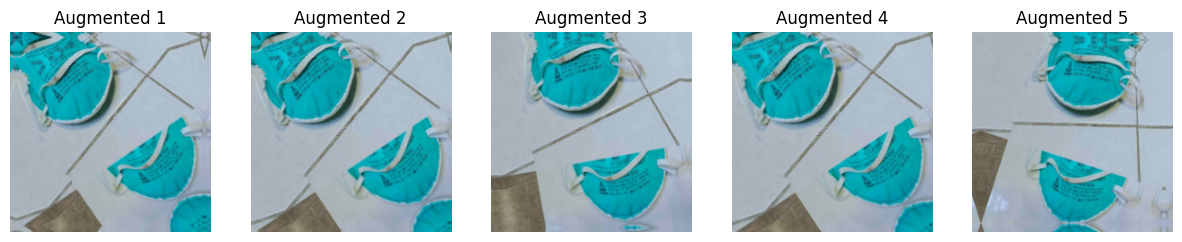

In [ ]:
def load_and_preprocess_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (224, 224))
    img = tf.cast(img, tf.float32) / 255.0
    return img

image_path = train_paths[0]
image = load_and_preprocess_image(image_path)
image_batch = tf.expand_dims(image, 0)

num_examples = 5
plt.figure(figsize=(15, 5))
for i in range(num_examples):
    augmented_image = data_augmentation(image_batch, training=True)
    augmented_image = tf.squeeze(augmented_image, axis=0)
    plt.subplot(1, num_examples, i + 1)
    plt.imshow(augmented_image.numpy())
    plt.axis('off')
    plt.title(f'Augmented {i+1}')
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import EfficientNetB3
def build_fine_tuned_model(base_model_fn, input_shape, num_classes, fine_tune_at=100):
    base_model = base_model_fn(include_top=False, weights="imagenet", input_shape=input_shape)
    base_model.trainable = True

    for layer in base_model.layers[:fine_tune_at]:
        layer.trainable = False

    inputs = layers.Input(shape=input_shape)
    x = data_augmentation(inputs)
    x = base_model(x, training=True)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs)
    return model

model = build_fine_tuned_model(EfficientNetB3, (224, 224, 3), len(class_names), fine_tune_at=100)

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
from sklearn.model_selection import train_test_split

train_paths, val_paths, train_labels, val_labels = train_test_split(
    image_paths, labels, test_size=0.2, random_state=SEED, stratify=labels
)

train_ds = prepare_dataset(train_paths, train_labels, training=True)
val_ds = prepare_dataset(val_paths, val_labels, training=False)


In [ ]:
def train(model, model_name, train_ds, val_ds):
    print(f"[INFO] Training {model_name}...")
    model.compile(optimizer=optimizers.Adam(1e-4),
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])

    cb = [
        callbacks.EarlyStopping(patience=2, restore_best_weights=True),
        callbacks.ModelCheckpoint(f"{model_name}_best.keras", save_best_only=True),
        callbacks.ReduceLROnPlateau(patience=1)
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=cb
    )

    model.save(f"{model_name}_final.keras")
    return history
history = train(model, "EfficientNetB3", train_ds, val_ds)


[INFO] Training EfficientNetB3...
Epoch 1/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 215s 551ms/step - accuracy: 0.6411 - loss: 0.8537 - val_accuracy: 0.7880 - val_loss: 0.5913 - learning_rate: 1.0000e-04
Epoch 2/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 128s 460ms/step - accuracy: 0.8467 - loss: 0.4218 - val_accuracy: 0.9205 - val_loss: 0.2251 - learning_rate: 1.0000e-04
Epoch 3/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 127s 456ms/step - accuracy: 0.8897 - loss: 0.3017 - val_accuracy: 0.9466 - val_loss: 0.1579 - learning_rate: 1.0000e-04
Epoch 4/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 144s 460ms/step - accuracy: 0.9162 - loss: 0.2321 - val_accuracy: 0.9456 - val_loss: 0.1556 - learning_rate: 1.0000e-04
Epoch 5/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 129s 464ms/step - accuracy: 0.9360 - loss: 0.1866 - val_accuracy: 0.9529 - val_loss: 0.1429 - learning_rate: 1.0000e-04
Epoch 6/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 127s 455ms/step - accuracy: 0.9461 - loss: 0.1552 - val_accuracy: 0.9635 - val_loss: 0.1221 - learning_rate: 1.0000e-04
Epoch 

[INFO] Evaluating model...
69/69 ━━━━━━━━━━━━━━━━━━━━ 20s 201ms/step
                  precision    recall  f1-score   support

      Food_Waste       1.00      0.98      0.99      1014
 Hazardous_Waste       0.95      0.98      0.97       495
Recyclable_Waste       0.95      0.96      0.96       489
  Residual_Waste       0.94      0.94      0.94       191

        accuracy                           0.97      2189
       macro avg       0.96      0.96      0.96      2189
    weighted avg       0.97      0.97      0.97      2189



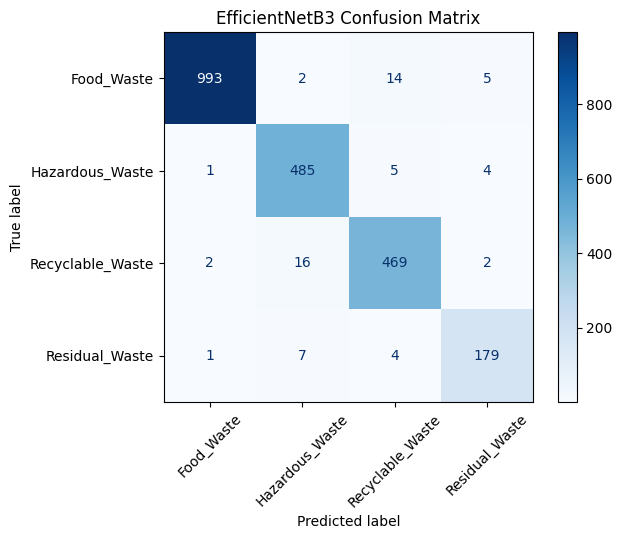

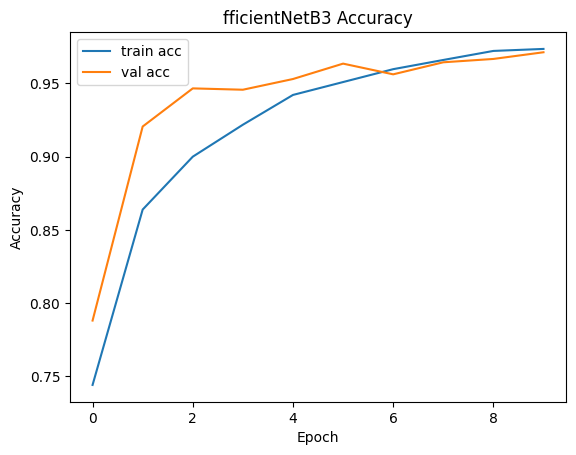

In [ ]:
print("[INFO] Evaluating model...")
preds = model.predict(val_ds)
y_pred = np.argmax(preds, axis=1)

y_true = np.concatenate([y.numpy() for _, y in val_ds], axis=0)
y_true = np.argmax(y_true, axis=1)

print(classification_report(y_true, y_pred, target_names=class_names))
cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(cmap="Blues")
plt.title(f"EfficientNetB3 Confusion Matrix")
plt.xticks(rotation=45)
plt.show()

plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.title('EfficientNetB3 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

img_width, img_height = 224, 224

def predict_image(img_path, model, class_names):
    img = cv2.imread(img_path)
    if img is None:
        print(f"Error: Could not read image at {img_path}")
        return None

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (img_width, img_height))
    img_array = np.expand_dims(img_resized.astype(np.float32), axis=0)
    img_array = preprocess_input(img_array)

    prediction = model.predict(img_array)
    predicted_index = np.argmax(prediction)
    predicted_class = class_names[predicted_index]
    confidence = np.max(prediction)

    plt.imshow(img_rgb)
    plt.title(f"Predicted: {predicted_class} ({confidence*100:.2f}%)")
    plt.axis('off')
    plt.show()

    return predicted_class


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


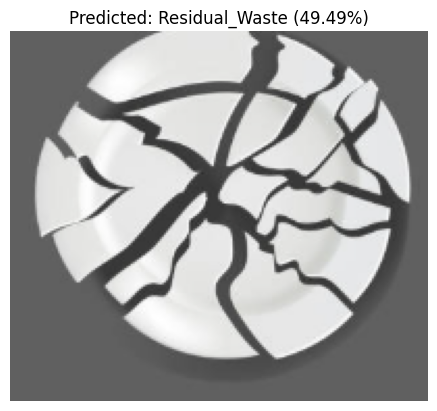

'Residual_Waste'

In [ ]:
# Example usage
predict_image("/content/Screenshot 2025-06-02 142254.png", model, class_names)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


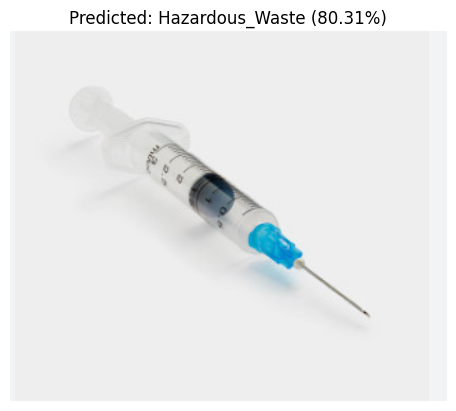

'Hazardous_Waste'

In [ ]:
# Example usage
predict_image("/content/Screenshot 2025-06-02 142830.png", model, class_names)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import DenseNet121
def build_fine_tuned_model(base_model_fn, input_shape, num_classes, fine_tune_at=100):
    base_model = base_model_fn(include_top=False, weights="imagenet", input_shape=input_shape)
    base_model.trainable = True

    for layer in base_model.layers[:fine_tune_at]:
        layer.trainable = False

    inputs = layers.Input(shape=input_shape)
    x = data_augmentation(inputs)
    x = base_model(x, training=True)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs)
    return model

model = build_fine_tuned_model(DenseNet121, (224, 224, 3), len(class_names), fine_tune_at=100)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
def train(model, model_name, train_ds, val_ds):
    print(f"[INFO] Training {model_name}...")
    model.compile(optimizer=optimizers.Adam(1e-4),
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])

    cb = [
        callbacks.EarlyStopping(patience=2, restore_best_weights=True),
        callbacks.ModelCheckpoint(f"{model_name}_best.keras", save_best_only=True),
        callbacks.ReduceLROnPlateau(patience=1)
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=cb
    )

    model.save(f"{model_name}_final.keras")
    return history
history = train(model, "DenseNet121", train_ds, val_ds)


[INFO] Training DenseNet121...
Epoch 1/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 233s 530ms/step - accuracy: 0.8674 - loss: 0.3598 - val_accuracy: 0.9836 - val_loss: 0.0488 - learning_rate: 1.0000e-04
Epoch 2/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 138s 494ms/step - accuracy: 0.9839 - loss: 0.0502 - val_accuracy: 0.9895 - val_loss: 0.0288 - learning_rate: 1.0000e-04
Epoch 3/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 142s 494ms/step - accuracy: 0.9914 - loss: 0.0276 - val_accuracy: 0.9904 - val_loss: 0.0283 - learning_rate: 1.0000e-04
Epoch 4/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 140s 489ms/step - accuracy: 0.9958 - loss: 0.0157 - val_accuracy: 0.9922 - val_loss: 0.0303 - learning_rate: 1.0000e-04
Epoch 5/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 143s 491ms/step - accuracy: 0.9965 - loss: 0.0121 - val_accuracy: 0.9945 - val_loss: 0.0206 - learning_rate: 1.0000e-05
Epoch 6/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 143s 493ms/step - accuracy: 0.9983 - loss: 0.0087 - val_accuracy: 0.9963 - val_loss: 0.0159 - learning_rate: 1.0000e-05
Epoch 7/1

[INFO] Evaluating model...
69/69 ━━━━━━━━━━━━━━━━━━━━ 19s 195ms/step
                  precision    recall  f1-score   support

      Food_Waste       1.00      1.00      1.00      1014
 Hazardous_Waste       1.00      0.99      0.99       495
Recyclable_Waste       0.99      1.00      0.99       489
  Residual_Waste       0.99      0.99      0.99       191

        accuracy                           1.00      2189
       macro avg       1.00      1.00      1.00      2189
    weighted avg       1.00      1.00      1.00      2189



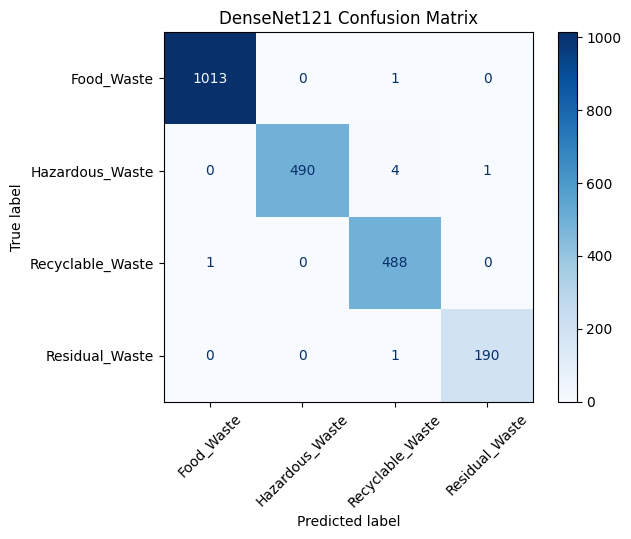

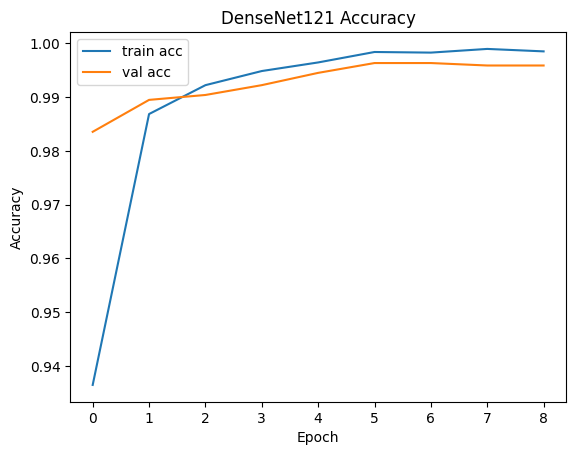

In [ ]:
print("[INFO] Evaluating model...")
preds = model.predict(val_ds)
y_pred = np.argmax(preds, axis=1)

y_true = np.concatenate([y.numpy() for _, y in val_ds], axis=0)
y_true = np.argmax(y_true, axis=1)

print(classification_report(y_true, y_pred, target_names=class_names))
cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(cmap="Blues")
plt.title(f"DenseNet121 Confusion Matrix")
plt.xticks(rotation=45)
plt.show()

plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.title('DenseNet121 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


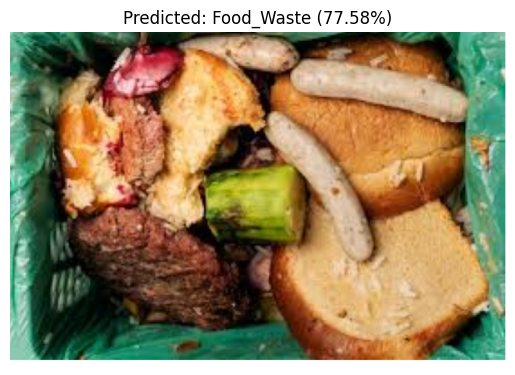

'Food_Waste'

In [ ]:
# Example usage
predict_image("/content/Screenshot 2025-06-03 233143.png", model, class_names)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


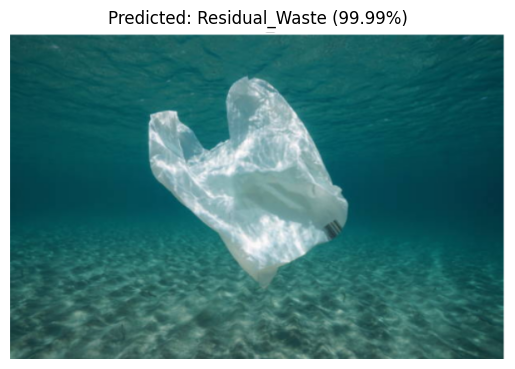

'Residual_Waste'

In [ ]:
# Example usage
predict_image("/content/Screenshot 2025-06-03 233237.png", model, class_names)